# Training Spiking Neural Nets in snnTorch from scratch
## By [Laurent Perrinet](https://laurentperrinet.github.io) heavily inspired by a tutorial by [Jason K. Eshraghian](https://www.ncg.ucsc.edu) given at [CONECT](https://conect-int.github.io/talk/2023-09-21-conect-seminar-by-jason-eshraghian/)


[<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/snntorch_alpha_w.png?raw=true' width="200">](https://github.com/jeshraghian/snntorch/)

## step 1: install the good python environmnent and dependencies 

In [1]:
%pip install snntorch  # shift + enter

Note: you may need to restart the kernel to use updated packages.


In [2]:
# imports
import snntorch as snn
from snntorch import spikeplot as splt
import torch

# plotting
import matplotlib.pyplot as plt
from IPython.display import HTML

Some utility functions that will be later necessary

In [3]:
#@title Plotting Settings
def plot_cur_mem_spk(cur, mem, spk, thr_line=False, vline=False, title=False, ylim_max1=1.25, ylim_max2=1.25):
  # Generate Plots
  fig, ax = plt.subplots(3, figsize=(8,6), sharex=True,
                        gridspec_kw = {'height_ratios': [1, 1, 0.4]})

  # Plot input current
  ax[0].plot(cur, c="tab:orange")
  ax[0].set_ylim([0, ylim_max1])
  ax[0].set_xlim([0, 200])
  ax[0].set_ylabel("Input Current ($I_{in}$)")
  if title:
    ax[0].set_title(title)

  # Plot membrane potential
  ax[1].plot(mem)
  ax[1].set_ylim([0, ylim_max2])
  ax[1].set_ylabel("Membrane Potential ($U_{mem}$)")
  if thr_line:
    ax[1].axhline(y=thr_line, alpha=0.25, linestyle="dashed", c="black", linewidth=2)
  plt.xlabel("Time step")

  # Plot output spike using spikeplot
  splt.raster(spk, ax[2], s=400, c="black", marker="|")
  if vline:
    ax[2].axvline(x=vline, ymin=0, ymax=6.75, alpha = 0.15, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  plt.ylabel("Output spikes")
  plt.yticks([])

  plt.show()

def plot_snn_spikes(spk_in, spk1_rec, spk2_rec, title):
  # Generate Plots
  fig, ax = plt.subplots(3, figsize=(8,7), sharex=True,
                        gridspec_kw = {'height_ratios': [1, 1, 0.4]})

  # Plot input spikes
  splt.raster(spk_in[:,0], ax[0], s=0.03, c="black")
  ax[0].set_ylabel("Input Spikes")
  ax[0].set_title(title)

  # Plot hidden layer spikes
  splt.raster(spk1_rec.reshape(num_steps, -1), ax[1], s = 0.05, c="black")
  ax[1].set_ylabel("Hidden Layer")

  # Plot output spikes
  splt.raster(spk2_rec.reshape(num_steps, -1), ax[2], c="black", marker="|")
  ax[2].set_ylabel("Output Spikes")
  ax[2].set_ylim([0, 10])

  plt.show()

def dvs_animator(spike_data):
  fig, ax = plt.subplots()
  anim = splt.animator((spike_data[:,0] + spike_data[:,1]), fig, ax)
  return anim


*What will I learn?*

**The Basics:**
1. The leaky integrate-and-fire (`snn.Leaky`) neuron in 5 mins
2. Train an SNN classifier using surrogate gradient descent

**Brain Data**
3. Load in your own data + train an SNN


**The Fancier Stuff**
4. Population Codes
5. Recurrent SNNs and Spiking LSTMs
6. Learning precise spike-timing
7. Hardware Friendly Training
  - Weight Quantization with Brevitas
  - State Quantization

# 1. The Leaky Integrate-and-Fire Neuron
### (...in 5 mins)



In [4]:
lif = snn.Leaky(beta=0.8, reset_mechanism="zero") # LIF neuron with a decay rate of 0.8

In [5]:
# setup inputs
num_steps = 200 # number of time-steps to simulate

x = torch.cat((torch.zeros(20), torch.ones(180)*0.20001)) # apply inputs

# initialize state + spike placeholder
mem = torch.zeros(1)
spk = torch.zeros(1)

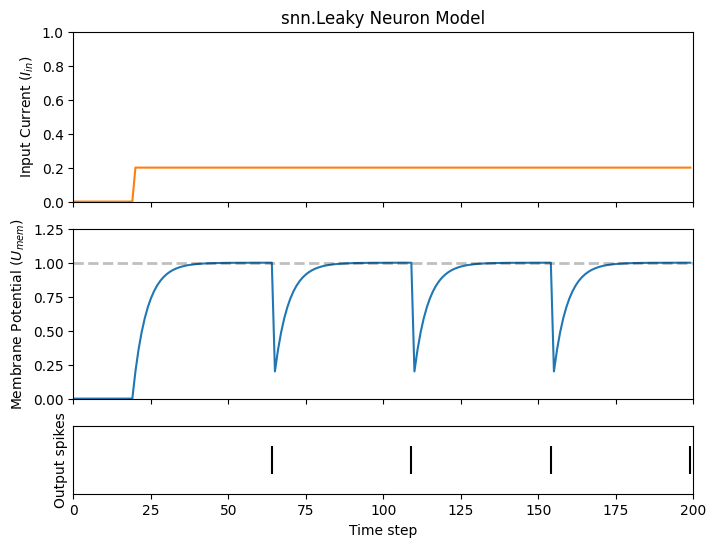

In [6]:
mem_rec = []
spk_rec = []

# neuron simulation
for step in range(num_steps):
  spk, mem = lif(x[step], mem) # generate mem and spk at next time step
  mem_rec.append(mem)
  spk_rec.append(spk)
  # store membrane and spikes in recording lists

# convert lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

plot_cur_mem_spk(x, mem_rec, spk_rec, thr_line=1, ylim_max1=1.0,
                 title="snn.Leaky Neuron Model")

# 2. Train an SNN Classifier
### (...in 10-ish mins)

In [7]:
# import
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import itertools

### Boilerplate: DataLoading the MNIST Dataset

In [8]:
# dataloader arguments
batch_size = 128
data_path='/data/mnist'

dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
## if you're on M1 or M2 GPU:
# device = torch.device("mps")

In [9]:
# Define a transform
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)

OSError: [Errno 30] Read-only file system: '/data'

In [10]:
# Create DataLoaders
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

NameError: name 'mnist_train' is not defined

## Construct a Fully Connected SNN

In [11]:
# Network Architecture
num_inputs = 28*28
num_hidden = 2000
num_outputs = 10

# Temporal Dynamics
num_steps = 25
beta = 0.99

In [12]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(num_inputs, num_hidden),
                    snn.Leaky(beta=beta, init_hidden=True),
                    nn.Linear(num_hidden, num_outputs),
                    snn.Leaky(beta=beta, init_hidden=True))


In [13]:
from snntorch import surrogate

# Define Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x):

        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky() # torch.zeros(batch_size)
        mem2 = self.lif2.init_leaky()

        # Record the final layer
        spk2_rec = []
        mem2_rec = []

        # time-loop
        for step in range(num_steps):
          cur1 = self.fc1(x.flatten(1)) # 128 x 784
          spk1, mem1 = self.lif1(cur1, mem1)
          cur2 = self.fc2(spk1)
          spk2, mem2 = self.lif2(cur2, mem2)

          # store outputs, spk2 and mem2, in list
          spk2_rec.append(spk2)
          mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0) # time-steps x batch x num_out

# Load the network onto CUDA if available
net = Net().to(device)

## Training the SNN

In [14]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))

num_epochs = 1 # 60000 / 128 = 468
counter = 0

# Outer training loop
for epoch in range(num_epochs):
    train_batch = iter(train_loader)

    # Minibatch training loop
    for data, targets in train_batch:
        data = data.to(device)
        targets = targets.to(device)

        # forward pass
        net.train()
        spk_rec, _ = net(data)

        # initialize the loss & sum over time
        loss_val = torch.zeros((1), dtype=dtype, device=device)
        loss_val = loss(spk_rec.sum(0), targets) #  batch x num_out

        # Gradient calculation + weight update
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        # Print train/test loss/accuracy
        if counter % 10 == 0:
            print(f"Iteration: {counter} \t Train Loss: {loss_val.item()}")
        counter += 1

        if counter == 100:
          break

NameError: name 'train_loader' is not defined

In [15]:
def measure_accuracy(model, dataloader):
  with torch.no_grad():
    model.eval()
    running_length = 0
    running_accuracy = 0

    for data, targets in iter(dataloader):
      data = data.to(device)
      targets = targets.to(device)

      # forward-pass
      spk_rec, _ = model(data)
      spike_count = spk_rec.sum(0) # batch x num_outputs
      _, max_spike = spike_count.max(1)

      # correct classes for one batch
      num_correct = (max_spike == targets).sum()

      # total accuracy
      running_length += len(targets)
      running_accuracy += num_correct

    accuracy = (running_accuracy / running_length)

    return accuracy.item()


In [16]:
print(f"Test set accuracy: {measure_accuracy(net, test_loader)}")

NameError: name 'test_loader' is not defined

## Convolutional SNN Classifier

In [17]:
# Define Network
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.conv1 = nn.Conv2d(1, 8, 5, padding="same")
        self.lif1 = snn.Leaky(beta=beta)
        self.mp1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(8, 24, 5, padding="same")
        self.lif2 = snn.Leaky(beta=beta)
        self.mp2 = nn.MaxPool2d(2)

        self.fc = nn.Linear(24 * 7 * 7, 10)
        self.lif3 = snn.Leaky(beta=beta)


    def forward(self, x):

        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        # Record the final layer
        spk3_rec = []
        mem3_rec = []

        # time-loop
        for step in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(self.mp1(cur1), mem1)
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(self.mp2(cur2), mem2)
            cur3 = self.fc(spk2.flatten(1))
            spk3, mem3 = self.lif3(cur3, mem3)

            spk3_rec.append(spk3)
            mem3_rec.append(mem3)

        return torch.stack(spk3_rec, dim=0), torch.stack(mem3_rec, dim=0)

# Load the network onto CUDA if available
convnet = ConvNet().to(device)

In [18]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(convnet.parameters(), lr=1e-4, betas=(0.9, 0.999))

num_epochs = 1
loss_hist = []
test_loss_hist = []
counter = 0

# Outer training loop
for epoch in range(num_epochs):
    train_batch = iter(train_loader)

    # Minibatch training loop
    for data, targets in train_batch:
        data = data.to(device)
        targets = targets.to(device)

        # forward pass
        convnet.train()
        spk_rec, _ = convnet(data)

        # initialize the loss & sum over time
        loss_val = torch.zeros((1), dtype=dtype, device=device)
        loss_val = loss(spk_rec.sum(0), targets)

        # Gradient calculation + weight update
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        # Store loss history for future plotting
        loss_hist.append(loss_val.item())

        # Print train/test loss/accuracy
        if counter % 10 == 0:
            print(f"Iteration: {counter} \t Train Loss: {loss_val.item()}")
        counter += 1

        if counter == 100:
          break

NameError: name 'train_loader' is not defined

In [19]:
def measure_accuracy(model, dataloader):
  with torch.no_grad():
    model.eval()
    running_length = 0
    running_accuracy = 0

    for data, targets in iter(dataloader):
      data = data.to(device)
      targets = targets.to(device)

      # forward-pass
      spk_rec, _ = model(data)
      spike_count = spk_rec.sum(0)
      _, max_spike = spike_count.max(1)

      # correct classes for one batch
      num_correct = (max_spike == targets).sum()

      # total accuracy
      running_length += len(targets)
      running_accuracy += num_correct

    accuracy = (running_accuracy / running_length)

    return accuracy.item()

print(f"ConvNet Accuracy: {measure_accuracy(convnet, test_loader)}")

NameError: name 'test_loader' is not defined

In [ ]:
from snntorch.functional import quant

# Define Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()


        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

# Load the network onto CUDA if available
net = Net().to(device)

That's all folks!